In [ ]:
import zipfile


zip_path = '/content/drive/Othercomputers/My Laptop/dataset/A Dataset of Multi-View Preclinical Tooth Preparat.zip'
extract_path = '/content/dataset'


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped")

Unzipped


In [ ]:
import zipfile
import os

# Inner zip file path
inner_zip_path = '/content/dataset/A Dataset of Multi-View Preclinical Tooth Preparat/Separate View Images.zip'
final_extract_path = '/content/dataset/extracted_images'

# Unzipping actual image collection
print("Extracting images from inner zip...")
with zipfile.ZipFile(inner_zip_path, 'r') as zip_ref:
    zip_ref.extractall(final_extract_path)

print("Images Unzipped")

# Check extracted structure
print("\nFoldes inside extracted_images:")
print(os.listdir(final_extract_path))

Extracting images from inner zip...
Images Unzipped

Foldes inside extracted_images:
['Separate View Images']


In [ ]:
import os
import shutil
import random

source_dir = '/content/dataset/extracted_images/Separate View Images'
base_dir = '/content/dataset/structured_dataset'

classes = ['Canines', 'Incisors', 'Molars', 'PreMolars']
split_ratio = 0.8

# Create Train & Val directories
for split in ['train', 'val']:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# Distribute images physically
for cls in classes:
    src_cls_path = os.path.join(source_dir, cls)
    images = os.listdir(src_cls_path)
    random.shuffle(images)

    train_count = int(len(images) * split_ratio)
    train_images = images[:train_count]
    val_images = images[train_count:]

    # Copy to train folder
    for img in train_images:
        shutil.copy(os.path.join(src_cls_path, img), os.path.join(base_dir, 'train', cls, img))

    # Copy to val folder
    for img in val_images:
        shutil.copy(os.path.join(src_cls_path, img), os.path.join(base_dir, 'val', cls, img))

print("✅ Physical Folder Structure Created Successfully!")
print("Paths: /content/dataset/structured_dataset/train & val")

✅ Physical Folder Structure Created Successfully!
Paths: /content/dataset/structured_dataset/train & val


In [ ]:
import os

images_base_path = '/content/dataset/extracted_images/Separate View Images'

print("Contents inside 'Separate View Images':")
print(os.listdir(images_base_path))

Contents inside 'Separate View Images':
['Incisors', 'PreMolars', 'Canines', 'Molars']


In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

basic_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

BATCH_SIZE = 32
train_path = '/content/dataset/structured_dataset/train'
val_path   = '/content/dataset/structured_dataset/val'

train_dataset = datasets.ImageFolder(train_path, transform=basic_transform)
val_dataset   = datasets.ImageFolder(val_path, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("✅ Success! Physical Dataset Loaders Ready.")
print("Classes detected:", train_dataset.classes)
print("Total train images:", len(train_dataset))
print("Total val images  :", len(val_dataset))

✅ Success! Physical Dataset Loaders Ready.
Classes detected: ['Canines', 'Incisors', 'Molars', 'PreMolars']
Total train images: 3077
Total val images  : 772


In [ ]:
import torch.nn as nn
import torch.optim as optim

# 1. Device configuration (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Simple CNN Model Architecture for 4 Classes
class ToothClassifier(nn.Module):
    def __init__(self):
        super(ToothClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Output: 32 x 75 x 75

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # Output: 64 x 37 x 37

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Output: 128 x 18 x 18
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 18 * 18, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 4) # 4 classes: Canines, Incisors, Molars, PreMolars
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = ToothClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model Architecture Ready!")

Using device: cuda
Model Architecture Ready!


In [ ]:
torch.save(model.state_dict(), 'tooth_classifier_model.pth')
print("✅ Model saved as 'tooth_classifier_model.pth'")

✅ Model saved as 'tooth_classifier_model.pth'


In [ ]:
# Training Loop (5 Epochs)
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total_train += labels.size(0)
        correct_train += predicted.eq(labels).sum().item()

    train_acc = 100. * correct_train / total_train

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total_val += labels.size(0)
            correct_val += predicted.eq(labels).sum().item()

    val_acc = 100. * correct_val / total_val

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f} | Val Acc: {val_acc:.2f}%")

print("\n🎉 Model Training Completed Successfully!")

Epoch [1/5] | Train Loss: 1.9252 | Train Acc: 65.32% | Val Loss: 0.4705 | Val Acc: 83.16%
Epoch [2/5] | Train Loss: 0.5745 | Train Acc: 77.19% | Val Loss: 0.4023 | Val Acc: 85.36%
Epoch [3/5] | Train Loss: 0.4448 | Train Acc: 81.87% | Val Loss: 0.3186 | Val Acc: 88.99%
Epoch [4/5] | Train Loss: 0.4030 | Train Acc: 84.66% | Val Loss: 0.3295 | Val Acc: 87.18%
Epoch [5/5] | Train Loss: 0.3617 | Train Acc: 86.19% | Val Loss: 0.2568 | Val Acc: 91.45%

🎉 Model Training Completed Successfully!


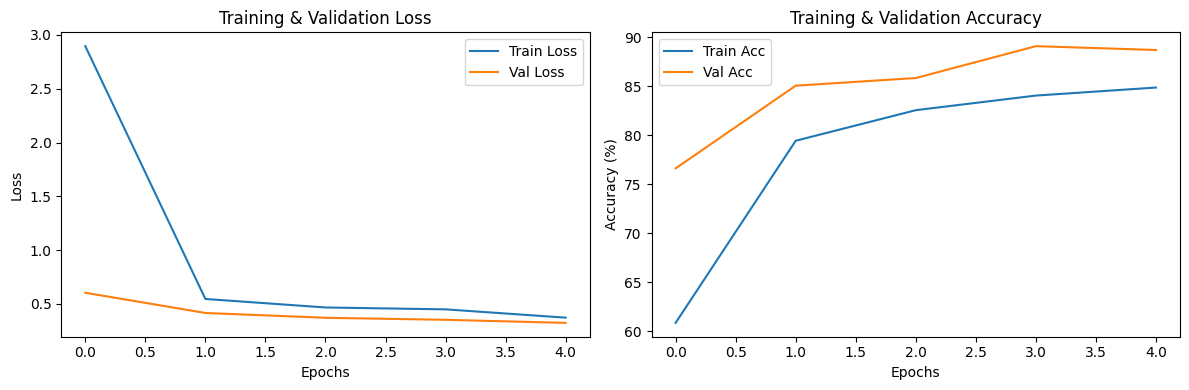

In [13]:
import matplotlib.pyplot as plt



plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot([2.8953, 0.5467, 0.4676, 0.4501, 0.3730], label='Train Loss')
plt.plot([0.6044, 0.4165, 0.3718, 0.3530, 0.3244], label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot([60.86, 79.44, 82.56, 84.05, 84.87], label='Train Acc')
plt.plot([76.62, 85.06, 85.84, 89.09, 88.70], label='Val Acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

     Canines       0.82      0.79      0.81       121
    Incisors       1.00      0.04      0.08        23
      Molars       0.95      0.97      0.96       320
   PreMolars       0.91      0.97      0.94       308

    accuracy                           0.91       772
   macro avg       0.92      0.69      0.70       772
weighted avg       0.92      0.91      0.90       772



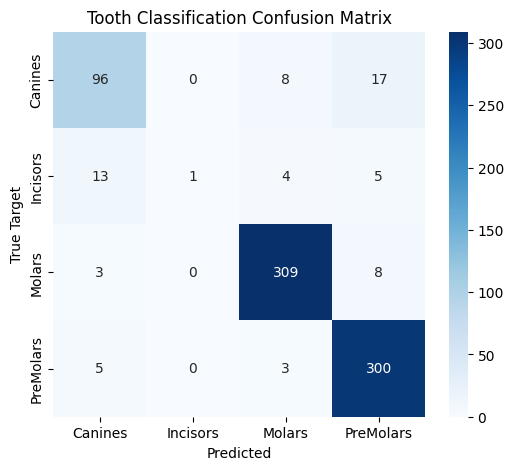

In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Print Classification Report (Precision, Recall, F1-score)
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True Target')
plt.title('Tooth Classification Confusion Matrix')
plt.show()